# Spatial Heterogeneity Analysis

In [84]:
space_cols = [
    'Exp_ID', 'Image_Metadata_Site', 'Image_Metadata_T',
    'ERKKTR_ratio', 'FoxO3A_ratio', 'Nuclear_size',
    'objNuclei_Location_Center_X', 'objNuclei_Location_Center_Y'
]

sample = pd.read_csv(DATA_PATH, usecols=space_cols, nrows=1_000_000,skiprows=range(1, 1_000_000))
sample['Mutation'] = sample['Image_Metadata_Site'].map(site_to_mutation)

site_time_counts = (
    sample
    .groupby(['Exp_ID', 'Image_Metadata_Site', 'Image_Metadata_T', 'Mutation'])
    .size()
    .reset_index(name='n_cells')
    .sort_values('n_cells', ascending=False)
)

# chosen = site_time_counts.iloc[100]
# exp_id = int(chosen['Exp_ID'])
# site_id = int(chosen['Image_Metadata_Site'])
# time_idx = int(chosen['Image_Metadata_T'])
# mutation = chosen['Mutation']
exp_id =1
site_id = 5
time_idx = 200

snapshot = (
    sample[
        (sample['Exp_ID'] == exp_id)
        & (sample['Image_Metadata_Site'] == site_id)
        & (sample['Image_Metadata_T'] == time_idx)
    ]
    .copy()
    .reset_index(drop=True)
)

print(f'Representative snapshot: Exp_ID={exp_id}, Site={site_id}, Mutation={mutation}, T={time_idx}')
print('Cells in snapshot:', len(snapshot))
display(snapshot.head())

Representative snapshot: Exp_ID=1, Site=5, Mutation=WT, T=200
Cells in snapshot: 1734


,Exp_ID,Image_Metadata_Site,Image_Metadata_T,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,objNuclei_Location_Center_X,objNuclei_Location_Center_Y,Mutation
0,1,5,200,233.000,0.910981,1.35045,816.27000,188.700,AKT1_E17K
1,1,5,200,293.000,0.742568,1.11778,196.67200,801.799,AKT1_E17K
2,1,5,200,241.000,0.869393,1.37521,593.08700,747.257,AKT1_E17K
3,1,5,200,247.000,0.871172,1.47833,8.42915,763.611,AKT1_E17K
4,1,5,200,259.001,0.799237,1.52129,207.64100,135.158,AKT1_E17K


In [83]:
sample["Image_Metadata_Site"].unique()
# sample["Exp_ID"].unique()

array([3, 4, 5, 6])

---

## Setup

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import sys, json, subprocess
import os
import tempfile

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import io
import imageio

from scipy.stats import mannwhitneyu

In [94]:
# ── project layout ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs/B2_exp_1_site_1_ERKKTR_ratio'

OUTPUT_ROOT.mkdir(exist_ok=True)

# ── spatiotemporal signal propagation graph construction parameters ────────────
EXP_ID        = 1
SITE_ID       = 1
SIGNAL_COL    = 'ERKKTR_ratio'
SPATIAL_RADIUS = 60
FUTURE_WINDOW  = 3
JUMP_QUANTILE  = 0.9

# ── helper: path to outputs for a given run ───────────────────────────────────
def output_dir(exp, site, signal=SIGNAL_COL):
    return OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}'

def load_summary(exp, site, signal=SIGNAL_COL):
    path = output_dir(exp, site, signal) / 'summary.json'
    with open(path) as f:
        return json.load(f)

print('Project root:', PROJECT_ROOT)
print('Data file exists:', DATA_PATH.exists())

Project root: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2
Data file exists: True


## Run

In [95]:
cmd = [
    sys.executable,
    str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
    '--data-path',           str(DATA_PATH),
    '--meta-path',           str(META_PATH),
    '--exp-id',              str(EXP_ID),
    '--site-id',             str(SITE_ID),
    '--signal-col',          SIGNAL_COL,
    '--spatial-radius',      str(SPATIAL_RADIUS),
    '--future-window-frames', str(FUTURE_WINDOW),
    '--jump-quantile',       str(JUMP_QUANTILE),
    '--output-dir',          str(OUTPUT_ROOT),
]

print('Running script …')
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Running script …

Spatiotemporal graph analysis complete.
Output directory: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2/analysis_outputs/B2_exp_1_site_1_ERKKTR_ratio/exp_1_site_1_ERKKTR_ratio
Mutation: WT
Nodes: 356,632
Spatial edges: 2,389,504
Temporal edges: 354,834
Jump threshold on ERKKTR_ratio: 0.0365
Interpretation of "jump": a large upward change since the previous frame.
Neighbour jump now means: at least one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no difference, >1 means more likely).



## Nodes classification as edge" or "central"
### Set edge margin parameter
TODO algorithm description

In [97]:
EDGE_MARGIN = 5

In [98]:
# 1. Загружаем сохраненный скриптом граф (таблицу вершин)
nodes = pd.read_csv(output_dir(EXP_ID, SITE_ID) / 'nodes.csv.gz')

def classify_frame_edges(group):
    x_low = np.percentile(group['objNuclei_Location_Center_X'], EDGE_MARGIN)
    x_high = np.percentile(group['objNuclei_Location_Center_X'], 100 - EDGE_MARGIN)
    y_low = np.percentile(group['objNuclei_Location_Center_Y'], EDGE_MARGIN)
    y_high = np.percentile(group['objNuclei_Location_Center_Y'], 100 - EDGE_MARGIN)

    is_edge = (
        (group['objNuclei_Location_Center_X'] <= x_low) |
        (group['objNuclei_Location_Center_X'] >= x_high) |
        (group['objNuclei_Location_Center_Y'] <= y_low) |
        (group['objNuclei_Location_Center_Y'] >= y_high)
    )
    return np.where(is_edge, 'edge', 'central')

# Применяем покадрово
nodes['spatial_category'] = nodes.groupby('Image_Metadata_T').apply(
    lambda g: pd.Series(classify_frame_edges(g), index=g.index)
).reset_index(level=0, drop=True)

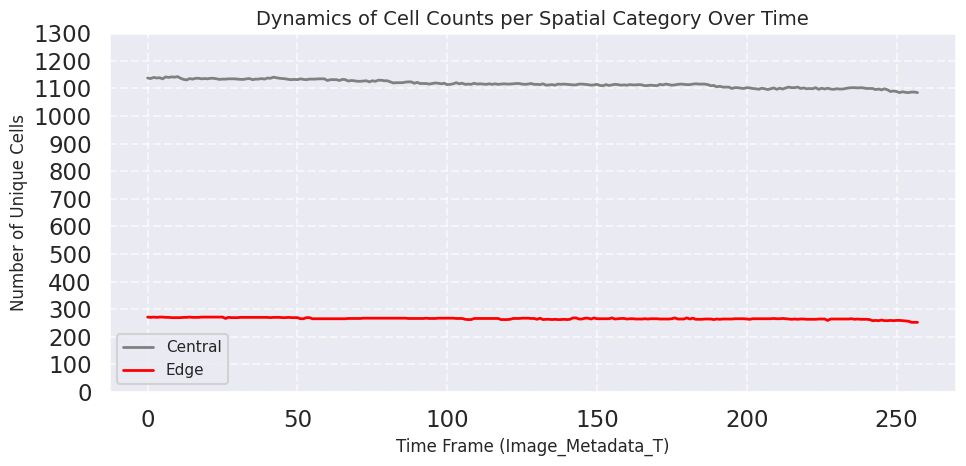

In [109]:

# We count unique track_ids at each time point (frame) for each spatial category
counts_per_frame = (
    nodes.groupby(["Image_Metadata_T", "spatial_category"])["track_id"]
    .nunique()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(10, 5))

# Plot central cells (gray)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["central"],
    color="gray",
    linestyle="-",
    linewidth=2,
    label="Central",
)

# Plot edge cells (red)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["edge"],
    color="red",
    linestyle="-",
    linewidth=2,
    label="Edge",
)

# Chart styling
ax.set_title("Dynamics of Cell Counts per Spatial Category Over Time", fontsize=14)
ax.set_xlabel("Time Frame (Image_Metadata_T)", fontsize=12)
ax.set_ylabel("Number of Unique Cells", fontsize=12)
ax.set_yticks(ticks = range(0, max(counts_per_frame["central"]) + 200,100))

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best", fontsize=11)

plt.tight_layout()
plt.show()

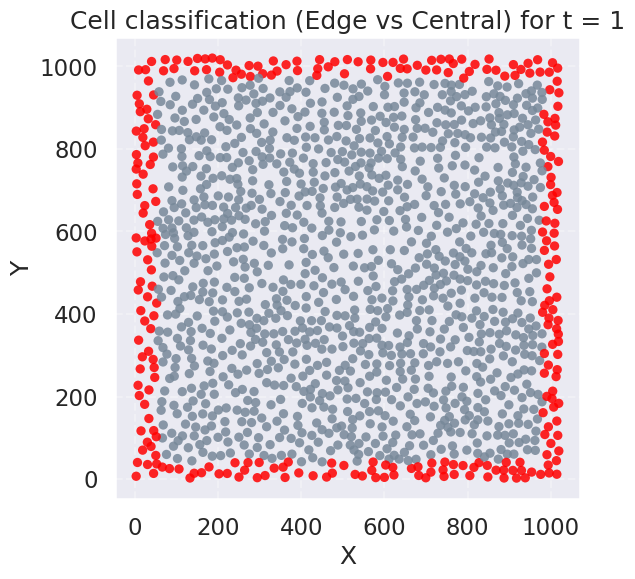

In [113]:
snapshot_time = 1
snapshot = nodes[nodes["Image_Metadata_T"] == snapshot_time]

# 4. Задаем цвета: красный для края, сине-серый для центра
colors = np.where(snapshot["spatial_category"] == "edge", "red", "lightslategray")

# 5. Отрисовка графика
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    snapshot["objNuclei_Location_Center_X"],
    snapshot["objNuclei_Location_Center_Y"],
    c=colors,  # Красный/серый массив цветов
    s=45,
    alpha=0.85,
    edgecolor="none",
)

ax.set_title(f"Spatial cell classification for t = {snapshot_time}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [118]:
# Sort time points to ensure chronological order in the GIF
time_points = sorted(nodes["Image_Metadata_T"].unique())

frames_images = []

print("Generating frames...")
for t in time_points:
    # Filter data for the current frame
    snapshot = nodes[nodes["Image_Metadata_T"] == t]

    # Map colors based on the dynamic spatial category
    colors = np.where(
        snapshot["spatial_category"] == "edge", "red", "lightslategray"
    )

    # Initialize the plot with fixed square dimensions
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        snapshot["objNuclei_Location_Center_X"],
        snapshot["objNuclei_Location_Center_Y"],
        c=colors,
        s=45,
        alpha=0.85,
        edgecolor="none",
    )
    # Labels and Titles
    ax.set_xlim(-50, 1050)
    ax.set_ylim(-50, 1050)
    ax.set_title(f"Spatial cell classification for t = {t}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    # Save the current plot directly to a memory buffer instead of writing files to disk
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=100)
    buf.seek(0)

    # Read the image from buffer and append to the frames list
    frames_images.append(imageio.v2.imread(buf))

    # Close the plot to release memory
    plt.close(fig)

# Save all gathered frames into an animated GIF
output_gif_path = "cell_propagation_boundaries.gif"
imageio.mimsave(output_gif_path, frames_images, fps=20, loop=0)

print(f"Done! Animated GIF successfully saved to: {output_gif_path}")

Generating frames...
Done! Animated GIF successfully saved to: cell_propagation_boundaries.gif
